### Apply KMeans clustering on the Employee_income.xlsx dataset and identify exact clusters using Elbow method to model the algorithm

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from sklearn.cluster import KMeans

In [2]:
#load data
df = pd.read_excel('Employee_income.xlsx')

In [3]:
df.head()

,Name,Age,Income
0,Amit,27,70000
1,Akash,29,90000
2,Shriya,29,61000
3,Anita,28,62000
4,Sudhir,42,155000


array([[<AxesSubplot:title={'center':'Age'}>,
        <AxesSubplot:title={'center':'Income'}>]], dtype=object)

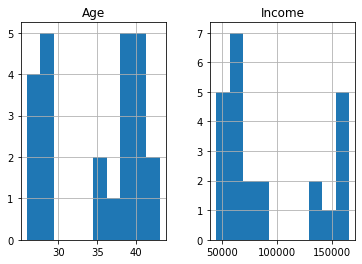

In [4]:
df.hist()

In [5]:
X = df[['Age','Income']]

In [6]:
X[:3]

,Age,Income
0,27,70000
1,29,90000
2,29,61000


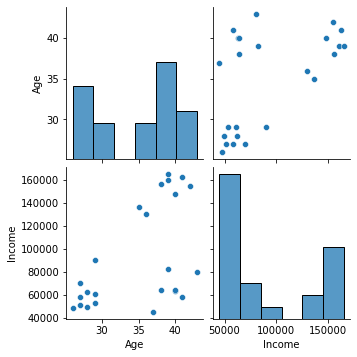

In [7]:
import seaborn as sns
sns.pairplot(X)

In [ ]:
#from sklearn.cluster import KMeans

In [17]:
# choose 3 cluster
# default n_clusters=8
model = KMeans(n_clusters=3)

In [18]:
model

KMeans(n_clusters=3)

In [19]:
#training: only X is used
model.fit(X)

KMeans(n_clusters=3)

In [20]:
X[:3]

,Age,Income
0,27,70000
1,29,90000
2,29,61000


In [21]:
model.labels_ # output clusters

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 2, 2, 0, 0,
       0, 1])

In [ ]:
#training Data X_train
#Testing Data X_test

In [23]:
model.predict([[26,20000]])

array([0])

In [24]:
# 3 centroids= 3 Clusters
model.cluster_centers_

array([[3.2500e+01, 5.6375e+04],
       [3.8750e+01, 1.5150e+05],
       [3.4500e+01, 8.0500e+04]])

In [25]:
model.cluster_centers_[:,0] #age data

array([32.5 , 38.75, 34.5 ])

In [26]:
model.cluster_centers_[:,1] #income data

array([ 56375., 151500.,  80500.])

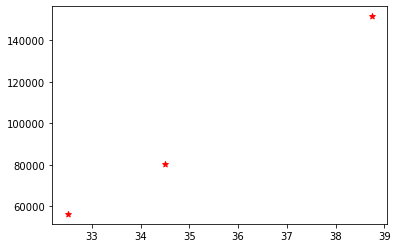

In [27]:
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],color='red',marker='*')

In [28]:
#Testing phase
model.fit_predict(X)

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 2, 2, 0, 0,
       0, 1])

In [29]:
X[:2]

,Age,Income
0,27,70000
1,29,90000


In [30]:
X['cluster']= model.fit_predict(X)

In [31]:
X

,Age,Income,cluster
0,27,70000,0
1,29,90000,0
2,29,61000,2
3,28,62000,2
4,42,155000,1
5,39,160000,1
6,41,162000,1
7,38,156000,1
8,36,130000,1
9,35,136000,1


In [32]:
X.shape

(24, 3)

In [33]:
df1 = X[X['cluster']==0]
df2 = X[X['cluster']==1]
df3 = X[X['cluster']==2]

In [34]:
df1[:2]

,Age,Income,cluster
0,27,70000,0
1,29,90000,0


In [35]:
df2[:2]

,Age,Income,cluster
4,42,155000,1
5,39,160000,1


In [36]:
df3[:2]

,Age,Income,cluster
2,29,61000,2
3,28,62000,2


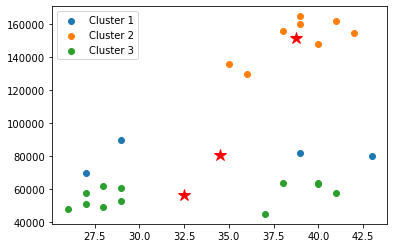

In [37]:
# Input data
plt.scatter(df1['Age'],df1['Income'],label='Cluster 1')
plt.scatter(df2['Age'],df2['Income'],label='Cluster 2')
plt.scatter(df3['Age'],df3['Income'],label='Cluster 3')
# Cluster centroids
plt.plot(model.cluster_centers_[:,0],model.cluster_centers_[:,1],color='red',marker='*',markersize=12,linestyle=' ')
plt.legend()

In [38]:
X[:3]

,Age,Income,cluster
0,27,70000,0
1,29,90000,0
2,29,61000,2


In [39]:
#Scaling is required for age and Income also
scaler = MinMaxScaler()#normalizer [0-1]
# mimax= X - min(x)/max(x)-min(x)
df['Income']=scaler.fit_transform(df[['Income']])


df['Age']=scaler.fit_transform(df[['Age']])

In [40]:
df

,Name,Age,Income
0,Amit,0.058824,0.208333
1,Akash,0.176471,0.375000
2,Shriya,0.176471,0.133333
3,Anita,0.117647,0.141667
4,Sudhir,0.941176,0.916667
5,Gajanan,0.764706,0.958333
6,Ranjit,0.882353,0.975000
7,Jyotsna,0.705882,0.925000
8,Nitish,0.588235,0.708333
9,Onkar,0.529412,0.758333


array([[<AxesSubplot:title={'center':'Age'}>,
        <AxesSubplot:title={'center':'Income'}>]], dtype=object)

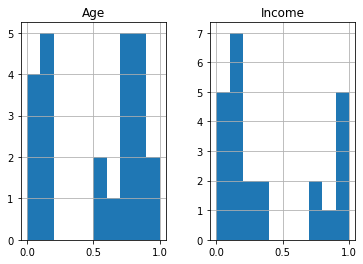

In [41]:
df.hist()

In [42]:
km = KMeans(n_clusters=3)

In [43]:
# age and Income are now Normalized
y_pred = km.fit_predict(df[['Age','Income']])

In [45]:
km.labels_

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 2,
       0, 1])

In [44]:
y_pred

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 2,
       0, 1])

In [46]:
df['Cluster']=y_pred

In [47]:
df[:3]

,Name,Age,Income,Cluster
0,Amit,0.058824,0.208333,0
1,Akash,0.176471,0.375000,0
2,Shriya,0.176471,0.133333,0


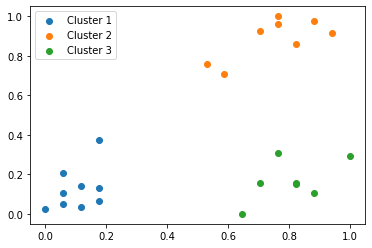

In [48]:
#Plotting after scaling
df1 = df[df['Cluster']==0]
df2 = df[df['Cluster']==1]
df3 = df[df['Cluster']==2]


plt.scatter(df1['Age'],df1['Income'],label='Cluster 1')
plt.scatter(df2['Age'],df2['Income'],label='Cluster 2')
plt.scatter(df3['Age'],df3['Income'],label='Cluster 3')
plt.legend()

In [49]:
#check the centroids of cluster
km.cluster_centers_

array([[0.10457516, 0.12731481],
       [0.75      , 0.8875    ],
       [0.80672269, 0.16785714]])

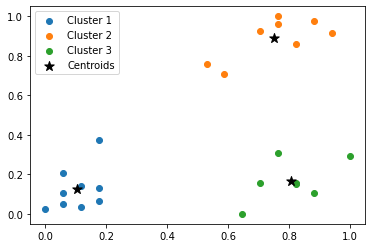

In [50]:
df1 = df[df['Cluster']==0]
df2 = df[df['Cluster']==1]
df3 = df[df['Cluster']==2]


plt.scatter(df1['Age'],df1['Income'],label='Cluster 1')
plt.scatter(df2['Age'],df2['Income'],label='Cluster 2')
plt.scatter(df3['Age'],df3['Income'],label='Cluster 3')

plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],s=100,marker='*',color='black',label='Centroids')

plt.legend()

In [51]:
km.predict([[25,56000]])

array([1])

In [53]:
km.predict([[0,100]])
# remember at the time testing also u must have to scale data

array([1])

In [54]:
test_data = df[['Age','Income']].sample(5)
test_data

,Age,Income
8,0.588235,0.708333
2,0.176471,0.133333
6,0.882353,0.975000
10,0.647059,0.000000
23,0.823529,0.858333


In [55]:
km.predict(test_data)

array([1, 0, 1, 2, 1])

# WCSS: within cluster sum of squared
### sum((pic1^2,pic2^2,pic3^2)

In [56]:
km

KMeans(n_clusters=3)

In [57]:
km.inertia_ #WCSS

0.4920193431403064

In [59]:
X = df[['Age','Income']]
X[:2]

,Age,Income
0,0.058824,0.208333
1,0.176471,0.375000


In [60]:
wcss = []
for i in range(1,11):#i will take 1 to 10 cluster
    km = KMeans(n_clusters=i)
    km.fit(X)
    wcss.append(km.inertia_)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [61]:
wcss

[5.9897601858860385,
 2.372901455312518,
 0.4920193431403064,
 0.331177199093145,
 0.2563456831364082,
 0.19373235103886324,
 0.1493781843721966,
 0.11815685924083684,
 0.09379987364635395,
 0.0705726413318595]

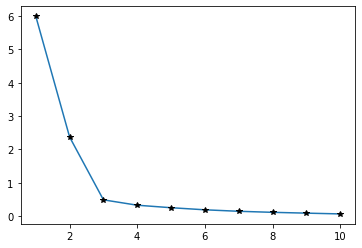

In [62]:
#check elbow: using Cluster vs inertia WCSS
plt.plot(range(1,11),wcss)
plt.plot(range(1,11),wcss,linestyle='',marker='*',color='k')

In [63]:
from sklearn.metrics import silhouette_score

In [64]:
X[:3]

,Age,Income
0,0.058824,0.208333
1,0.176471,0.375000
2,0.176471,0.133333


In [65]:
new = KMeans(n_clusters=2)

In [66]:
new.fit(X)

KMeans(n_clusters=2)

In [67]:
new.labels_

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0])

In [68]:
silhouette_score(X,new.labels_)

0.5371159667908988

In [ ]:
[-1,0,1]
If silhouette value is close to 1, 
sample is well-clustered and already assigned to a very appropriate cluster.

If silhouette value is about to 0, 
sample could be assign to another cluster closest to it and the sample 
lies equally far away from both the clusters. ...

If silhouette value is close to –1, 
sample is misclassified and is merely placed somewhere in between the clusters.

In [69]:
score = []
for i in range(2,6):
    new = KMeans(n_clusters=i)
    new.fit(X)
    print(i,':',silhouette_score(X,new.labels_))
'''
score.append(silhouette_score(X,new.labels_))
print(score)
'''

2 : 0.5371159667908988
3 : 0.7261322509367406
4 : 0.6919228048185123
5 : 0.5989901496296245


'\nscore.append(silhouette_score(X,new.labels_))\nprint(score)\n'

In [71]:
!pip install yellowbrick

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\programdata\\anaconda3\\lib\\site-packages\\scikit_learn-0.24.2.dist-info\\COPYING'
Consider using the `--user` option or check the permissions.




  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 0.24.2
    Uninstalling scikit-learn-0.24.2:


In [73]:
from yellowbrick.cluster import SilhouetteVisualizer

ModuleNotFoundError: No module named 'yellowbrick'

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(15,8))
for i in [2, 3, 4, 5]:
    '''
    Create KMeans instance for different number of clusters
    '''
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=42)
    q, mod = divmod(i, 2)
    '''
    Create SilhouetteVisualizer instance with KMeans instance
    Fit the visualizer
    '''
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-1][mod])
    visualizer.fit(X) 